# Concepts of Bias and Variance

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_1.png" alt="sample" width="1000"/>

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_2.png" alt="sample" width="1000"/>

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_3.png" alt="sample" width="1000"/>

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_4.png" alt="sample" width="1000"/>

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_5.png" alt="sample" width="1000"/>

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/bias_variance_tradeoff.png" alt="sample" width="1000"/>

# Insights & Inferences of KNN algorithm

##### Advantages of KNN :

Simple to understand and implement. <br>
Few hyperparameters. <br>
Works well with small datasets. <br>

##### Limitations of KNN :

Slow with large datasets (computes distance for all points). <br>
Curse of dimensionality (More number of features). <br>
Entire training data is memorized. <br>
Sensitive to irrelevant or unscaled features. <br>
Choice of k is critical: <br>
    Too small → noisy predictions and may lead to overfitting.  <br>
    Too large → overly smooth predictions. <br>

##### Question to ponder : Do you need to scale the input features before applying KNN ?

Yes. As KNN relies on distance metrics, Scaling (especially for numerical features) ensures 
all features contribute equally to the distance calculation.

# Evaluation metrics

<img src="./images/Confusion_matrix_1.png" alt="sample" width="1000"/>

<img src="./images/Confusion_matrix_2.png" alt="sample" width="1000"/>

<img src="./images/Sensitivity_1.png" alt="sample" width="1000"/>

<img src="./images/Sensitivity_2.png" alt="sample" width="1000"/>

<img src="./images/Specificity_1.png" alt="sample" width="1000"/>

<img src="./images/Specificity_2.png" alt="sample" width="1000"/>

<img src="./images/Precision.png" alt="sample" width="1000"/>

<img src="./images/False_positive_rate.png" alt="sample" width="1000"/>

<img src="./images/ROC_AUC_1.png" alt="sample" width="1000"/>

<img src="./images/ROC_AUC_2.png" alt="sample" width="1000"/>

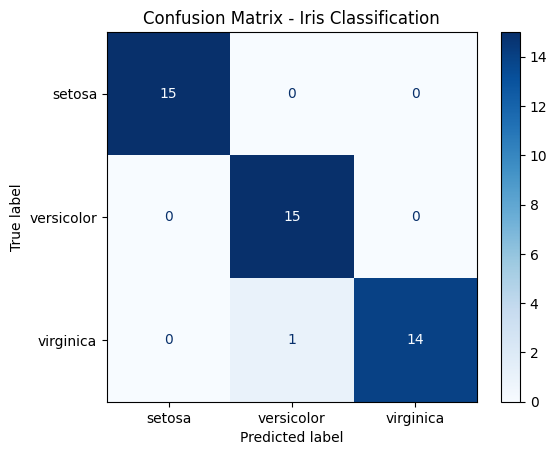

📊 Evaluation Metrics:

Accuracy: 0.9778
Precision (macro):  0.9792
Recall (macro):     0.9778
F1 Score (macro):   0.9778
Precision (weighted): 0.9792
Recall (weighted):    0.9778
F1 Score (weighted):  0.9778

Detailed Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

predict_proba : [[0.  0.  1. ]
 [0.  0.8 0.2]
 [0.  0.4 0.6]
 [0.  0.8 0.2]
 [0.  0.4 0.6]
 [0.  0.  1. ]
 [0.  1.  0. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [1.  0.  0. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  0.  1. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [1.  0.  0. ]
 [1.  0.  0. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  1.  0. ]
 [0.  0.  1. ]
 

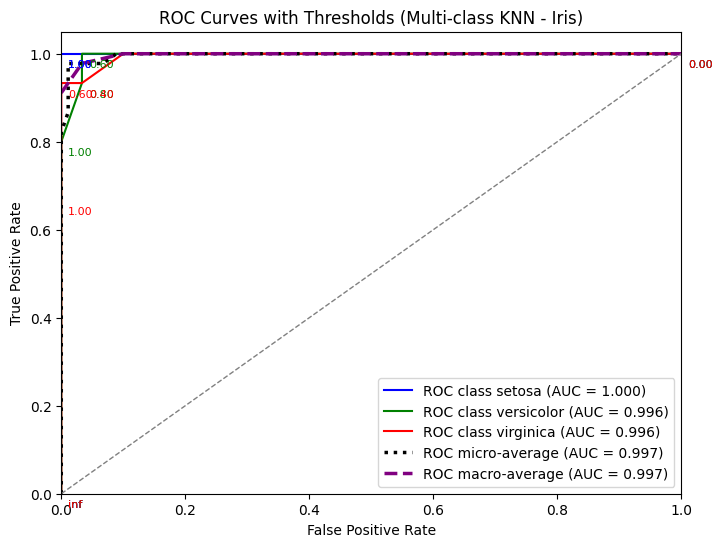

In [ ]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names  

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# Train model (KNN)
# -----------------------------
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Confusion Matrix (plot)
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Iris Classification")
plt.show()

# -----------------------------
# Evaluation Metrics (print)
# -----------------------------
print("📊 Evaluation Metrics:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Precision (macro):  {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro):     {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score (macro):   {f1_score(y_test, y_pred, average='macro'):.4f}")

print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score (weighted):  {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# -----------------------------
# ROC Curves (multi-class)
# -----------------------------
# KNN supports predict_proba; get class probabilities for test set
y_score = model.predict_proba(X_test)

print("predict_proba :", y_score)

# Binarize the test labels for one-vs-rest ROC computation
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# -----------------------------
# Plot ROC Curves with thresholds
# -----------------------------
plt.figure(figsize=(8,6))

colors = ["blue", "green", "red"]
for i in range(n_classes):
    fpr[i], tpr[i], thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    print("thresholds", thresholds)
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC curve
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=1.5,
             label=f"ROC class {class_names[i]} (AUC = {roc_auc[i]:.3f})")
    
    # Annotate thresholds (pick ~5 evenly spaced points)
    for j in np.linspace(0, len(thresholds)-1, 5, dtype=int):
        plt.annotate(f"{thresholds[j]:.2f}",
                     (fpr[i][j], tpr[i][j]),
                     textcoords="offset points",
                     xytext=(5, -10), fontsize=8, color=colors[i])

# Micro and Macro averages
plt.plot(fpr["micro"], tpr["micro"], lw=2.5, linestyle=":", color="black",
         label=f"ROC micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], lw=2.5, linestyle="--", color="purple",
         label=f"ROC macro-average (AUC = {roc_auc['macro']:.3f})")

# Diagonal chance line
plt.plot([0, 1], [0, 1], lw=1, linestyle="--", color="gray")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with Thresholds (Multi-class KNN - Iris)")
plt.legend(loc="lower right")
plt.show()

# Spam email classification

Confusion Matrix:
 [[0 2]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         2
        Spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

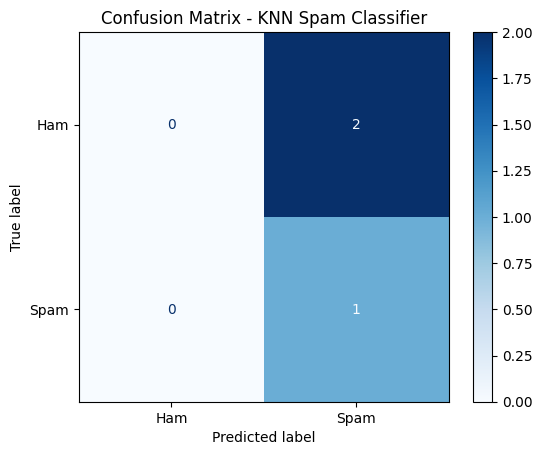

Additional Metrics:
Accuracy:            0.3333
Precision (Spam=1):  0.3333
Recall (Spam=1):     1.0000
F1 (Spam=1):         0.5000


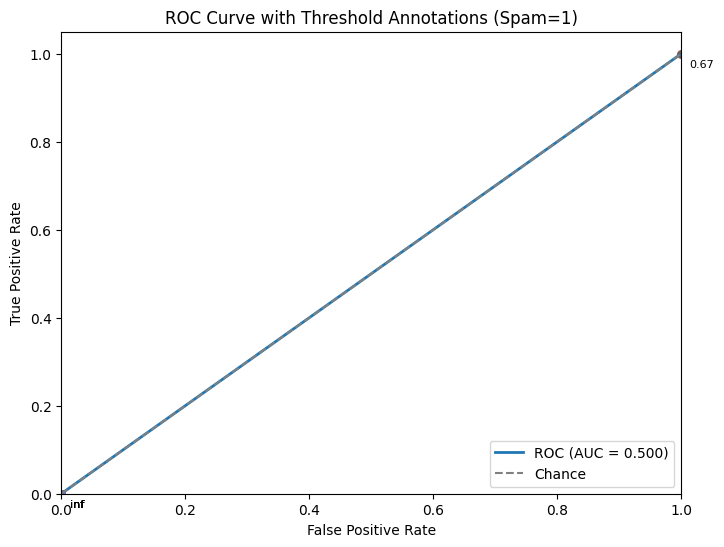

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sample dataset
# -----------------------------
emails = [
    "Congratulations, you have won a free lottery ticket",
    "Earn money fast, click this link now",
    "Limited time offer, claim your prize",
    "Meeting scheduled tomorrow at 10am",
    "Project deadline is next week",
    "Please find attached the meeting notes",
    "You have been selected for a cash reward",
    "Can we reschedule the presentation?",
    "Exclusive deal for you, act now",
    "Lunch at 1pm today?"
]
labels = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]  # 1 = spam, 0 = ham

# Define simple spammy keywords
spam_keywords = ["win", "offer", "free", "money", "prize", "deal", "reward"]

# Feature extraction function
def extract_features(email):
    length = len(email)
    words = len(email.split())
    keyword_count = sum(word in email.lower() for word in spam_keywords)
    exclamations = email.count("!")
    return [length, words, keyword_count, exclamations]

# Create feature matrix
X = np.array([extract_features(email) for email in emails])
y = np.array(labels)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# KNN classifier
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predictions (hard labels)
y_pred = knn.predict(X_test)

# Probabilities (needed for ROC/PR)
y_proba = knn.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation - Confusion Matrix & Report
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - KNN Spam Classifier")
plt.show()

# -----------------------------
# Additional Metrics
# -----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print("Additional Metrics:")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (Spam=1):  {prec:.4f}")
print(f"Recall (Spam=1):     {rec:.4f}")
print(f"F1 (Spam=1):         {f1:.4f}")

# -----------------------------
# ROC Curve (with threshold annotations)
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")

# Annotate ~6 thresholds along the curve
idxs = np.linspace(0, len(thresholds)-1, 6, dtype=int)
for i in idxs:
    x, y_pt = fpr[i], tpr[i]
    thr = thresholds[i]
    plt.scatter([x], [y_pt], s=30)
    plt.annotate(f"{thr:.2f}", (x, y_pt), textcoords="offset points", xytext=(6, -10), fontsize=8)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold Annotations (Spam=1)")
plt.legend(loc="lower right")
plt.show()

<img src="./images/roc_curve_characteristics.png" alt="sample" width="1000"/>